# Exercise 10 — Karate Club Split



In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random

G = nx.karate_club_graph()

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected:", nx.is_connected(G))

clubs = pd.Series([G.nodes[n]["club"] for n in G.nodes()]).value_counts()
clubs

Nodes: 34
Edges: 78
Connected: True


,count
Mr. Hi,17
Officer,17


## 2. Dynamic model choice

We use a **threshold model** for opinion alignment.

This fits the Karate Club topic because members may switch faction alignment if enough of their social neighbors support the other side.

### Node state

Each node has one of two states:

- `0` = aligned with **Mr. Hi**
- `1` = aligned with **Officer**

### Transition rule

At each time step, a node checks the fraction of its neighbors that support the opposite opinion.

If the fraction of neighbors with the opposite opinion is greater than or equal to a threshold, the node switches opinion.

This is a simple model of social pressure and local influence.


## 3. Helper functions

The functions below initialize opinions, run the threshold model, and record how the process changes over time.


In [2]:
def known_split_state(graph):
    """Initial state based on the real club labels."""
    return {
        n: 0 if graph.nodes[n]["club"] == "Mr. Hi" else 1
        for n in graph.nodes()
    }

def single_seed_state(graph, seed_node, seed_opinion=1, default_opinion=0):
    """All nodes start with default opinion except one seed node."""
    return {
        n: seed_opinion if n == seed_node else default_opinion
        for n in graph.nodes()
    }

def multiple_seed_state(graph, seed_nodes, seed_opinion=1, default_opinion=0):
    """All nodes start with default opinion except selected seed nodes."""
    return {
        n: seed_opinion if n in seed_nodes else default_opinion
        for n in graph.nodes()
    }

def run_threshold_model(graph, initial_state, threshold=0.5, steps=15):
    """Run synchronous threshold updates over time."""
    states = [initial_state.copy()]
    records = []

    for t in range(steps + 1):
        current = states[-1]
        count_0 = sum(1 for s in current.values() if s == 0)
        count_1 = sum(1 for s in current.values() if s == 1)
        records.append({
            "time": t,
            "state_0_Mr_Hi": count_0,
            "state_1_Officer": count_1,
            "fraction_Officer": count_1 / graph.number_of_nodes()
        })

        if t == steps:
            break

        next_state = current.copy()
        for node in graph.nodes():
            neighbors = list(graph.neighbors(node))
            if len(neighbors) == 0:
                continue

            current_opinion = current[node]
            opposite_opinion = 1 - current_opinion
            opposite_neighbors = sum(1 for nbr in neighbors if current[nbr] == opposite_opinion)
            opposite_fraction = opposite_neighbors / len(neighbors)

            if opposite_fraction >= threshold:
                next_state[node] = opposite_opinion

        states.append(next_state)

    return pd.DataFrame(records), states

## 4. Select initial seed nodes

We compare several scenarios.

Important nodes from earlier exercises:

- node `0`: faction leader on the Mr. Hi side,
- node `33`: faction leader on the Officer side,
- node `32`: high-degree / boundary-like member near the Officer faction,
- node `2`: high-betweenness connector.

At least one scenario uses a central node from earlier exercises, as required.


In [3]:
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)

important_nodes_df = pd.DataFrame({
    "node": [0, 33, 32, 2],
    "club": [G.nodes[n]["club"] for n in [0, 33, 32, 2]],
    "degree": [degree[n] for n in [0, 33, 32, 2]],
    "betweenness": [betweenness[n] for n in [0, 33, 32, 2]]
}).sort_values("betweenness", ascending=False)

important_nodes_df

,node,club,degree,betweenness
0,0,Mr. Hi,16,0.437635
1,33,Officer,17,0.304075
2,32,Officer,12,0.145247
3,2,Mr. Hi,10,0.143657


## 5. Scenario A: central seed versus random seed

In this experiment, everyone initially supports Mr. Hi (`0`) except one seed node that supports Officer (`1`).

We compare:

- central seed: node `33`, a faction leader,
- random seed: a randomly selected non-leader node.


In [4]:
random.seed(42)
non_leaders = [n for n in G.nodes() if n not in [0, 33]]
random_seed = random.choice(non_leaders)

central_seed = 33

central_initial = single_seed_state(G, seed_node=central_seed, seed_opinion=1, default_opinion=0)
random_initial = single_seed_state(G, seed_node=random_seed, seed_opinion=1, default_opinion=0)

central_run, central_states = run_threshold_model(G, central_initial, threshold=0.3, steps=15)
random_run, random_states = run_threshold_model(G, random_initial, threshold=0.3, steps=15)

central_run["scenario"] = f"Central seed node {central_seed}"
random_run["scenario"] = f"Random seed node {random_seed}"

scenario_a_df = pd.concat([central_run, random_run], ignore_index=True)
scenario_a_df.head(20)

,time,state_0_Mr_Hi,state_1_Officer,fraction_Officer,scenario
0,0,33,1,0.029412,Central seed node 33
1,1,25,9,0.264706,Central seed node 33
2,2,32,2,0.058824,Central seed node 33
3,3,20,14,0.411765,Central seed node 33
4,4,29,5,0.147059,Central seed node 33
5,5,18,16,0.470588,Central seed node 33
6,6,28,6,0.176471,Central seed node 33
7,7,14,20,0.588235,Central seed node 33
8,8,26,8,0.235294,Central seed node 33
9,9,11,23,0.676471,Central seed node 33


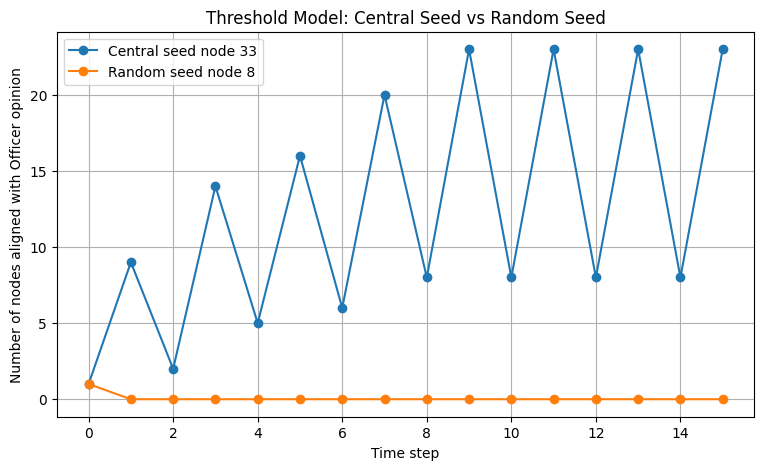

In [5]:
plt.figure(figsize=(9, 5))

for scenario, group in scenario_a_df.groupby("scenario"):
    plt.plot(group["time"], group["state_1_Officer"], marker="o", label=scenario)

plt.xlabel("Time step")
plt.ylabel("Number of nodes aligned with Officer opinion")
plt.title("Threshold Model: Central Seed vs Random Seed")
plt.legend()
plt.grid(True)
plt.show()

## 6. Scenario B: low threshold versus high threshold

In this experiment, the initial seeds are important Officer-side nodes: `33` and `32`.

We compare:

- low threshold: members switch more easily,
- high threshold: members require stronger local pressure before switching.


In [6]:
seed_nodes = [33, 32]

initial_seeds = multiple_seed_state(G, seed_nodes=seed_nodes, seed_opinion=1, default_opinion=0)

low_threshold_run, low_threshold_states = run_threshold_model(
    G,
    initial_seeds,
    threshold=0.3,
    steps=15
)

high_threshold_run, high_threshold_states = run_threshold_model(
    G,
    initial_seeds,
    threshold=0.6,
    steps=15
)

low_threshold_run["scenario"] = "Low threshold 0.3"
high_threshold_run["scenario"] = "High threshold 0.6"

scenario_b_df = pd.concat([low_threshold_run, high_threshold_run], ignore_index=True)
scenario_b_df.head(20)

,time,state_0_Mr_Hi,state_1_Officer,fraction_Officer,scenario
0,0,32,2,0.058824,Low threshold 0.3
1,1,20,14,0.411765,Low threshold 0.3
2,2,29,5,0.147059,Low threshold 0.3
3,3,18,16,0.470588,Low threshold 0.3
4,4,28,6,0.176471,Low threshold 0.3
5,5,14,20,0.588235,Low threshold 0.3
6,6,26,8,0.235294,Low threshold 0.3
7,7,11,23,0.676471,Low threshold 0.3
8,8,26,8,0.235294,Low threshold 0.3
9,9,11,23,0.676471,Low threshold 0.3


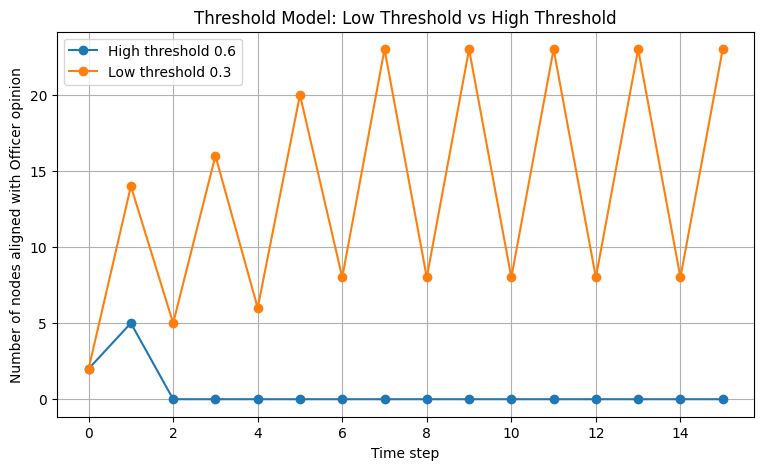

In [7]:
plt.figure(figsize=(9, 5))

for scenario, group in scenario_b_df.groupby("scenario"):
    plt.plot(group["time"], group["state_1_Officer"], marker="o", label=scenario)

plt.xlabel("Time step")
plt.ylabel("Number of nodes aligned with Officer opinion")
plt.title("Threshold Model: Low Threshold vs High Threshold")
plt.legend()
plt.grid(True)
plt.show()

## 7. Scenario C: known split as initial state

Here the initial state is the real split already stored in the graph.  
This tests whether the known faction alignment is stable under local threshold pressure.


In [8]:
known_initial = known_split_state(G)

known_run, known_states = run_threshold_model(
    G,
    known_initial,
    threshold=0.5,
    steps=15
)

known_run

,time,state_0_Mr_Hi,state_1_Officer,fraction_Officer
0,0,17,17,0.500000
1,1,18,16,0.470588
2,2,17,17,0.500000
3,3,18,16,0.470588
4,4,17,17,0.500000
5,5,18,16,0.470588
6,6,17,17,0.500000
7,7,18,16,0.470588
8,8,17,17,0.500000
9,9,18,16,0.470588


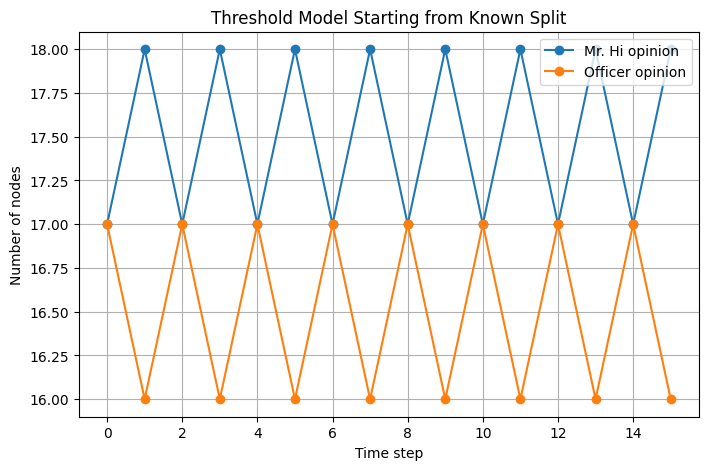

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(known_run["time"], known_run["state_0_Mr_Hi"], marker="o", label="Mr. Hi opinion")
plt.plot(known_run["time"], known_run["state_1_Officer"], marker="o", label="Officer opinion")

plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.title("Threshold Model Starting from Known Split")
plt.legend()
plt.grid(True)
plt.show()

## 8. Final state visualization

We visualize the final state of the low-threshold scenario, where influence can spread more easily.


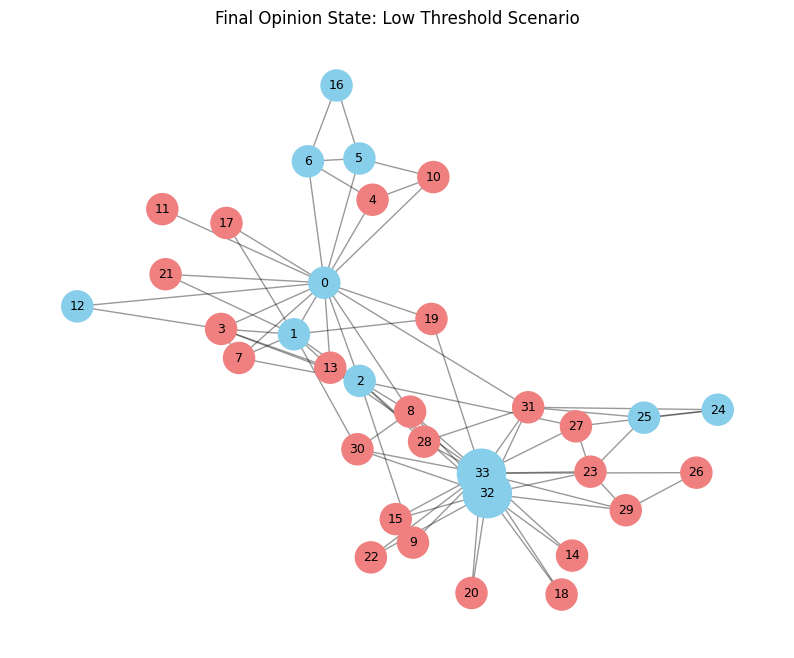

In [10]:
final_state = low_threshold_states[-1]
pos = nx.spring_layout(G, seed=42)

node_colors = []
for n in G.nodes():
    if final_state[n] == 0:
        node_colors.append("skyblue")
    else:
        node_colors.append("lightcoral")

node_sizes = []
for n in G.nodes():
    if n in seed_nodes:
        node_sizes.append(1200)
    else:
        node_sizes.append(500)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Final Opinion State: Low Threshold Scenario")
plt.axis("off")
plt.show()

## 9. Compare final outcomes

This table compares the final number of nodes in each opinion state across scenarios.


In [11]:
final_summary = pd.DataFrame([
    {
        "scenario": f"Central seed node {central_seed}, threshold 0.3",
        "final_Mr_Hi": central_run.iloc[-1]["state_0_Mr_Hi"],
        "final_Officer": central_run.iloc[-1]["state_1_Officer"]
    },
    {
        "scenario": f"Random seed node {random_seed}, threshold 0.3",
        "final_Mr_Hi": random_run.iloc[-1]["state_0_Mr_Hi"],
        "final_Officer": random_run.iloc[-1]["state_1_Officer"]
    },
    {
        "scenario": "Seeds 33 and 32, low threshold 0.3",
        "final_Mr_Hi": low_threshold_run.iloc[-1]["state_0_Mr_Hi"],
        "final_Officer": low_threshold_run.iloc[-1]["state_1_Officer"]
    },
    {
        "scenario": "Seeds 33 and 32, high threshold 0.6",
        "final_Mr_Hi": high_threshold_run.iloc[-1]["state_0_Mr_Hi"],
        "final_Officer": high_threshold_run.iloc[-1]["state_1_Officer"]
    },
    {
        "scenario": "Known split initial state, threshold 0.5",
        "final_Mr_Hi": known_run.iloc[-1]["state_0_Mr_Hi"],
        "final_Officer": known_run.iloc[-1]["state_1_Officer"]
    }
])

final_summary

,scenario,final_Mr_Hi,final_Officer
0,"Central seed node 33, threshold 0.3",11.0,23.0
1,"Random seed node 8, threshold 0.3",34.0,0.0
2,"Seeds 33 and 32, low threshold 0.3",11.0,23.0
3,"Seeds 33 and 32, high threshold 0.6",34.0,0.0
4,"Known split initial state, threshold 0.5",18.0,16.0
